In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d
import copy

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
colors = ['r', 'b', 'g', 'm', 'y']
#k_out = [0.65]#[0.1, 1, 10, 100] # h/Mpc
k_out_in_h = [0.1]#, 0.1, 1]
k_out = [i*h_planck for i in k_out_in_h]
k_out = [0.01, 0.1, 1]  # 1/Mpc    Los k tienen que estar en unidades de 1/Mpc para estas funciones.
mass = 1.e-25 # eV

precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-6
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,'Omega_cdm':omega_cdm/h_planck**2,'100*theta_s': theta_s,'ln10^{10}A_s' : As
                 ,'n_s':ns,'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl mPk','gauge':'synchronous',#'matter_source_in_current_gauge': 'yes',
                  'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk', 
                  'Omega_k' : 0., 'N_ncdm' : 0, 'k_output_values':str(k_out).strip('[]')}
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()
perturbations_lcdm = copy.deepcopy(all_k_lcdm)
all_k_lcdm = 0

common_settings  = {
            'output':'tCl mPk',
            'h' : h_planck,
            'Omega_cdm': 0,
            'omega_b' : omega_b,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_scf' : omega_cdm/h_planck**2,
            'attractor_ic_scf' : 'yes',
            'scf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass,
            'scf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl mPk',
            'k_output_values':str(k_out).strip('[]'),
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'A_s' : As,
            'n_s' : ns,
            'format': 'camb',
            } 
common_settings.update(precision_settings)

### $k = 10 \,Mpc{-1}$ 

In [4]:
k_in_h = 10
mass = 1.e-25
k = k_in_h*0.67556

lcdm = Class()
lcdm.set(lcdm_settings)
lcdm.set({'k_output_values':str(k)})
lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
perturbations_lcdm = copy.deepcopy(all_k_lcdm)
background_lcdm = lcdm.get_background()

cosmo = Class()
cosmo.set(common_settings)
cosmo.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
cosmo.set({'k_output_values':str(k)})
cosmo.compute()
perts = copy.deepcopy(cosmo.get_perturbations())
cosmo.struct_cleanup()
cosmo.empty()


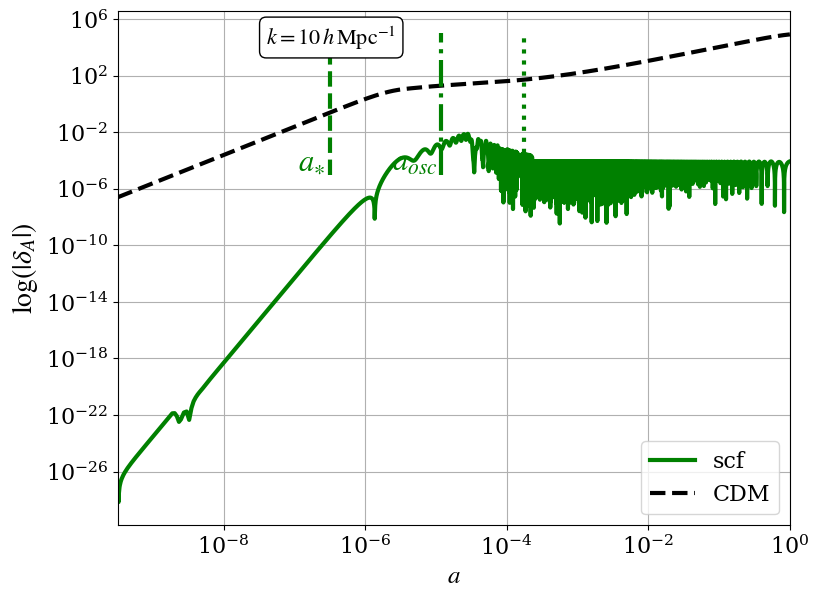

In [5]:
# DELTA  k = 10
plt.figure(figsize=(8, 6))
one_k = perts['scalar'][0]     # this contains only the scalar perturbations for the requested k values
one_k_lcdm = perturbations_lcdm['scalar'][0]
delta_vf = one_k['delta_scf']
delta_lcdm = one_k_lcdm['delta_cdm']
a = one_k['a']
a_lcdm = one_k_lcdm['a']
h = cosmo.h()
background_z = background_lcdm['z'] # read redshift
background_a = 1/(1+background_z)
rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)
a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

data = np.column_stack((a, delta_vf))
np.savetxt('../../SFDM_data/delta_scf/delta_scf_m={%s}_k=%s' % (str(mass)[-3:],str(k_in_h)), np.asarray(data))

background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

plt.xlabel(r'$a$', size=18)
plt.ylabel(r'$\log(|\delta_A|)$', size=20)
plt.loglog(a, np.abs(delta_vf), color='g', label=r'scf', lw=3)
plt.loglog(a_lcdm, np.abs(delta_lcdm), 'k--', label=r'CDM', lw=3)
plt.vlines(k_over_aH, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashdot',lw=3)
plt.vlines(a_equality(1.), ymin=1.e-5, ymax=1.e5,color='g',linestyle='dotted',lw=3)
plt.text(0.28*a_equality(1.), 2*1.e-5, r'$a_{eq}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(0.2*a_osc, 2*1.e-5, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(0.35*k_over_aH, 2*1.e-5, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.legend(loc='lower right', fontsize=16)
plt.text(4.e-8, 0.2*max(np.abs(delta_lcdm)), r'$k =  %s \,h\,\rm{Mpc}^{-1}$' % str(k_in_h), bbox=dict(facecolor='white', boxstyle='round',alpha=1.), size=16)
plt.grid()
plt.xlim(a[0], 1)
plt.tight_layout()
plt.tick_params(axis='both',labelsize=16)
plt.show()

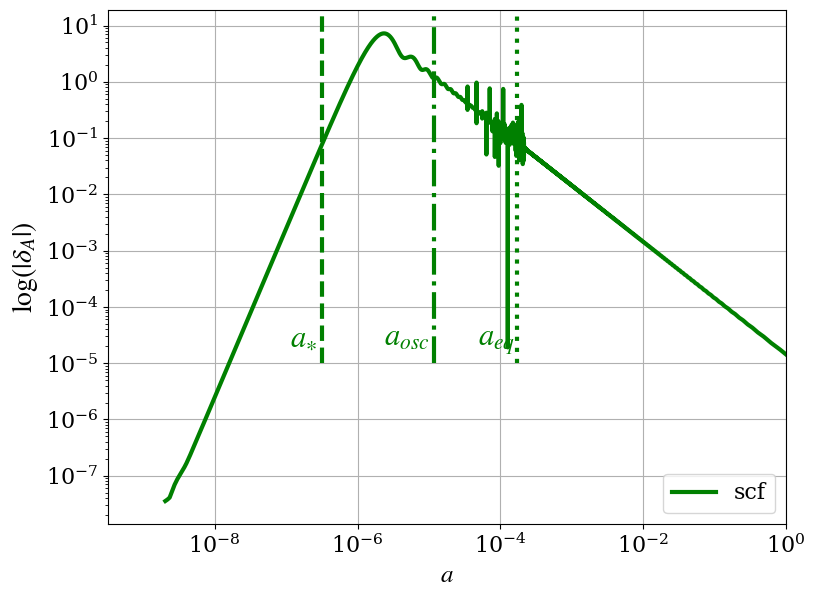

In [6]:
# THETA  k = 10
plt.figure(figsize=(8, 6))
one_k = perts['scalar'][0]     # this contains only the scalar perturbations for the requested k values
one_k_lcdm = perturbations_lcdm['scalar'][0]
theta_vf = one_k['theta_scf']
theta_b_scf = one_k['theta_b']
theta_b_lcdm = one_k_lcdm['theta_b']
a = one_k['a']
a_lcdm = one_k_lcdm['a']
h = cosmo.h() 
background_z = background_lcdm['z'] # read redshift
background_a = 1/(1+background_z)
rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)
a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

data = np.column_stack((a, theta_vf))
np.savetxt('../../SFDM_data/delta_scf/theta_scf_m={%s}_k=%s' % (str(mass)[-3:],str(k_in_h)), np.asarray(data))

background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

plt.xlabel(r'$a$', size=18)
plt.ylabel(r'$\log(|\delta_A|)$', size=20)
plt.loglog(a, np.abs(theta_vf), color='g', label=r'scf', lw=3)
plt.vlines(k_over_aH, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashdot',lw=3)
plt.vlines(a_equality(1.), ymin=1.e-5, ymax=1.e5,color='g',linestyle='dotted',lw=3)
plt.text(0.28*a_equality(1.), 2*1.e-5, r'$a_{eq}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(0.2*a_osc, 2*1.e-5, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(0.35*k_over_aH, 2*1.e-5, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.legend(loc='lower right', fontsize=16)
plt.grid()
plt.xlim(a[0], 1)
plt.tight_layout()
plt.tick_params(axis='both',labelsize=16)
plt.show()

### $k = 0.1 \,Mpc{-1}$ 

In [7]:
k_in_h = 0.1
mass = 1.e-25
k = k_in_h*0.67556

lcdm = Class()
lcdm.set(lcdm_settings)
lcdm.set({'k_output_values':str(k)})
lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
perturbations_lcdm = copy.deepcopy(all_k_lcdm)
background_lcdm = lcdm.get_background()

cosmo = Class()
cosmo.set(common_settings)
cosmo.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
cosmo.set({'k_output_values':str(k)})
cosmo.compute()


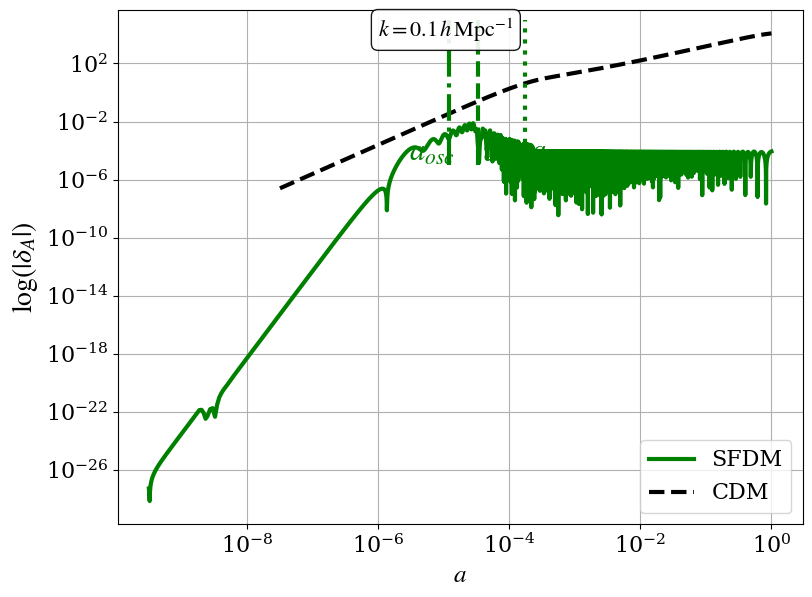

In [8]:
# DELTA  k = 0.1
plt.figure(figsize=(8, 6))
one_k = perts['scalar'][0]     # this contains only the scalar perturbations for the requested k values
one_k_lcdm = perturbations_lcdm['scalar'][0]
delta_vf = one_k['delta_scf']
delta_lcdm = one_k_lcdm['delta_cdm']
a = one_k['a']
a_lcdm = one_k_lcdm['a']
h = cosmo.h() # get reduced Hubble for conversions to 1/Mpc
background_a = 1/(1+background_z)
rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)
a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

data = np.column_stack((a, delta_vf))
np.savetxt('../../SFDM_data/delta_scf/delta_scf_m={%s}_k=%s' % (str(mass)[-3:],str(k_in_h)), np.asarray(data))

background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

plt.xlabel(r'$a$', size=18)
plt.ylabel(r'$\log(|\delta_A|)$', size=20)
plt.loglog(a, np.abs(delta_vf), color='g', label=r'SFDM', lw=3)
plt.loglog(a_lcdm, np.abs(delta_lcdm), 'k--', label=r'CDM', lw=3)
plt.vlines(k_over_aH, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashdot',lw=3)
plt.vlines(a_equality(1.), ymin=1.e-5, ymax=1.e5,color='g',linestyle='dotted',lw=3)
plt.text(1.2*a_equality(1.), 2*1.e-5, r'$a_{eq}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(0.25*a_osc, 2*1.e-5, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(1.2*k_over_aH, 2*1.e-5, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.legend(loc='lower right', fontsize=16)
plt.text(1.e-6, 7.e3, r'$k =  %s \,h\,\rm{Mpc}^{-1}$' % str(k_in_h), bbox=dict(facecolor='white', boxstyle='round',alpha=0.9), size=16)
plt.grid()
plt.tight_layout()
plt.tick_params(axis='both',labelsize=16)
plt.show()

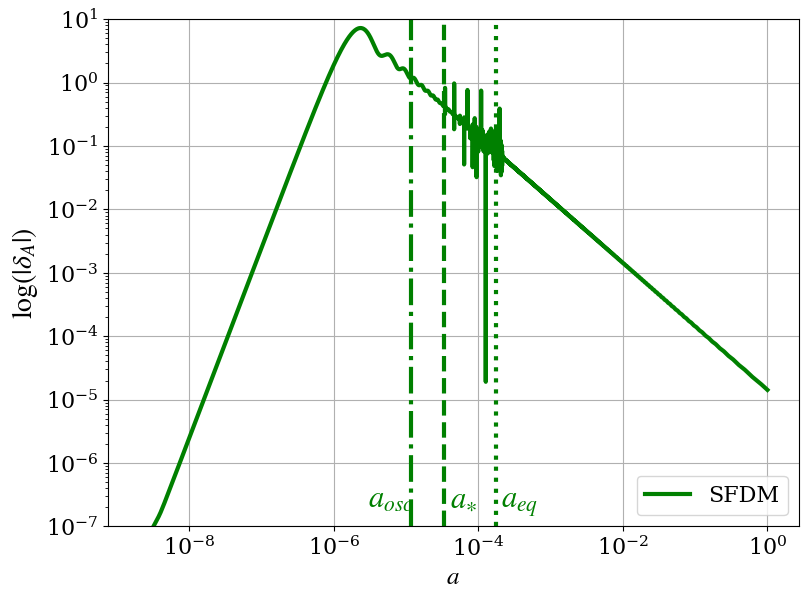

In [9]:
# THETA  k = 0.1
plt.figure(figsize=(8, 6))
one_k = perts['scalar'][0]     # this contains only the scalar perturbations for the requested k values
one_k_lcdm = perturbations_lcdm['scalar'][0]
theta_vf = one_k['theta_scf']
theta_b_scf = one_k['theta_b']
theta_b = one_k_lcdm['theta_b']
a = one_k['a']
a_lcdm = one_k_lcdm['a']
h = cosmo.h() 
background_z = background_lcdm['z'] # read redshift
background_a = 1/(1+background_z)
rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)
a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

data = np.column_stack((a, theta_vf))
np.savetxt('../../SFDM_data/delta_scf/theta_scf_m={%s}_k=%s' % (str(mass)[-3:],str(k_in_h)), np.asarray(data))

background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

plt.xlabel(r'$a$', size=18)
plt.ylabel(r'$\log(|\delta_A|)$', size=20)
plt.loglog(a, np.abs(theta_vf), color='g', label=r'SFDM', lw=3)
plt.vlines(k_over_aH, ymin=1.e-7, ymax=1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-7, ymax=1.e5,color='g',linestyle='dashdot',lw=3)
plt.vlines(a_equality(1.), ymin=1.e-7, ymax=1.e5,color='g',linestyle='dotted',lw=3)
plt.text(1.2*a_equality(1.), 2*1.e-7, r'$a_{eq}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(0.25*a_osc, 2*1.e-7, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(1.2*k_over_aH, 2*1.e-7, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.legend(loc='lower right', fontsize=16)
plt.grid()
plt.ylim(1.e-7, 1.e1)
plt.tight_layout()
plt.tick_params(axis='both',labelsize=16)
plt.show()